# Phase 2 — Data Pipeline Test
Run every cell top to bottom. Each cell prints a clear PASS / FAIL so you know exactly where things stand before moving to Phase 3.

---
## Cell 1 — Imports & version check

In [2]:
import sys
import importlib

required = {
    'yfinance':    '0.2',
    'pandas':      '2.0',
    'numpy':       '1.24',
    'ta':          '0.10',
    'sklearn':     '1.3',
    'joblib':      '1.3',
}

all_ok = True
for pkg, min_ver in required.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        status = 'OK' if ver >= min_ver else 'OLD'
        print(f"  {'[PASS]' if status=='OK' else '[WARN]'}  {pkg:<15} {ver}")
        if status == 'OLD':
            all_ok = False
    except ImportError:
        print(f"  [FAIL]  {pkg:<15} NOT INSTALLED")
        all_ok = False

print()
print(f"Python: {sys.version.split()[0]}")
print()
if all_ok:
    print("==> All dependencies present. Proceed to Cell 2.")
else:
    print("==> Fix missing packages first: pip install yfinance pandas numpy ta scikit-learn joblib")

  [PASS]  yfinance        1.2.0
  [PASS]  pandas          2.3.3
  [PASS]  numpy           2.4.3
  [PASS]  ta              unknown
  [PASS]  sklearn         1.8.0
  [PASS]  joblib          1.5.3

Python: 3.12.4

==> All dependencies present. Proceed to Cell 2.


---
## Cell 2 — Download raw OHLCV

In [3]:
import yfinance as yf
import pandas as pd

TICKER = "AAPL"
START  = "2013-01-01"
END    = "2024-12-31"

print(f"Downloading {TICKER} from {START} to {END} ...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=True)

# Fix: flatten multi-level columns (yfinance 0.2.x returns ('Close','AAPL') etc.)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
    print("[INFO] Multi-level columns detected and flattened.")

# Diagnostics
print()
print(f"Shape      : {raw.shape}")
print(f"Columns    : {raw.columns.tolist()}")
print(f"Date range : {raw.index[0].date()} --> {raw.index[-1].date()}")
print(f"Nulls      : {raw.isnull().sum().sum()}")
print()

# Assertions
assert not raw.empty,                        "FAIL: DataFrame is empty — no data returned"
assert raw.shape[0] > 2500,                  "FAIL: Expected ~2700+ rows, got less"
assert set(['Close','High','Low','Open','Volume']).issubset(raw.columns), \
    f"FAIL: Missing expected columns. Got: {raw.columns.tolist()}"
assert raw.isnull().sum().sum() == 0,        "FAIL: NaN values found in raw data"
assert (raw['Volume'] > 0).all(),            "FAIL: Zero-volume rows found"
assert raw.index.is_monotonic_increasing,    "FAIL: Dates are not in order"

print("[PASS] Download complete.")
print()
raw.head(3)

[*********************100%***********************]  1 of 1 completed

[INFO] Multi-level columns detected and flattened.

Shape      : (3019, 5)
Columns    : ['Close', 'High', 'Low', 'Open', 'Volume']
Date range : 2013-01-02 --> 2024-12-30
Nulls      : 0

[PASS] Download complete.



Price,Close,High,Low,Open,Volume
Date,,,,,
2013-01-02,16.596678,16.777146,16.372984,16.741476,560518000
2013-01-03,16.387190,16.616024,16.353938,16.561914,352965200
2013-01-04,15.930740,16.282305,15.895372,16.232125,594333600


---
## Cell 3 — Plot raw price & volume

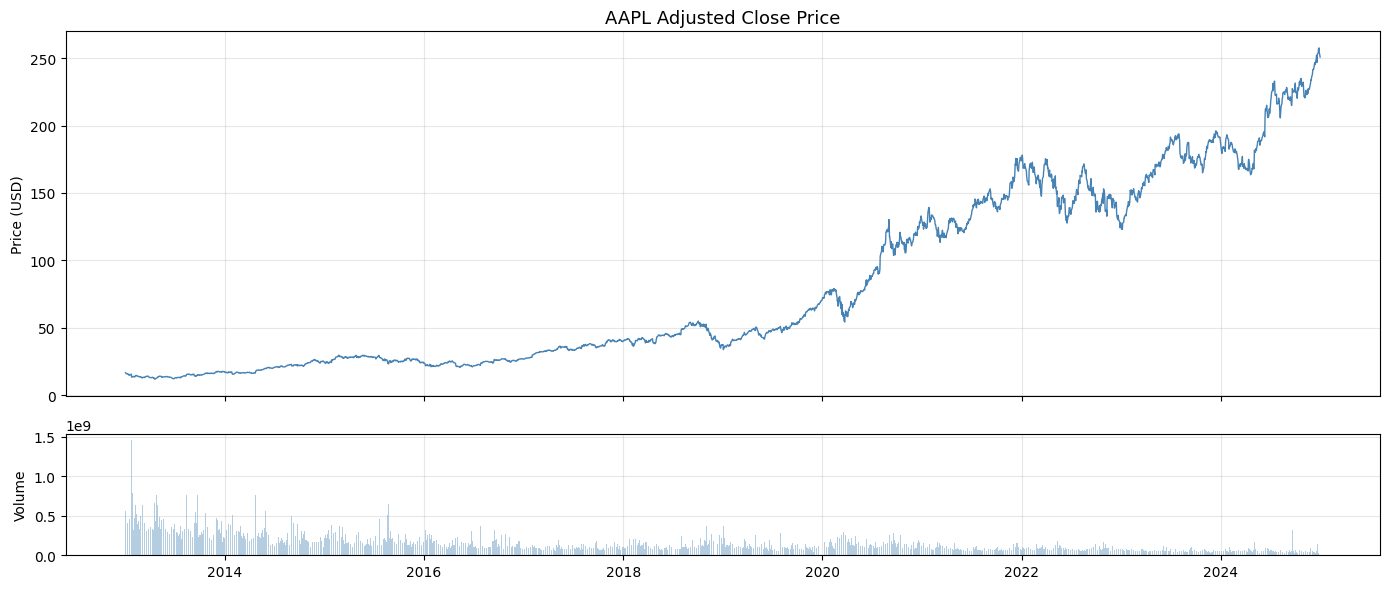

[PASS] Price chart rendered. Visually inspect for obvious anomalies (e.g. sudden zero prices).


In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(raw.index, raw['Close'], linewidth=1, color='steelblue')
ax1.set_title(f'{TICKER} Adjusted Close Price', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.bar(raw.index, raw['Volume'], color='steelblue', alpha=0.4, width=1)
ax2.set_ylabel('Volume')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("[PASS] Price chart rendered. Visually inspect for obvious anomalies (e.g. sudden zero prices).")

---
## Cell 4 — Feature engineering (all 6 indicators)

In [5]:
import ta

df = raw.copy()
c, h, l, v = df['Close'], df['High'], df['Low'], df['Volume']

df['rsi']      = ta.momentum.RSIIndicator(c, window=14).rsi()
df['macd']     = ta.trend.MACD(c).macd_diff()          # histogram, not raw line
df['ema_20']   = ta.trend.EMAIndicator(c, window=20).ema_indicator()
df['ema_50']   = ta.trend.EMAIndicator(c, window=50).ema_indicator()
df['bb_width'] = (
    ta.volatility.BollingerBands(c).bollinger_hband() -
    ta.volatility.BollingerBands(c).bollinger_lband()
) / c
df['obv']      = ta.volume.OnBalanceVolumeIndicator(c, v).on_balance_volume()
df['atr']      = ta.volatility.AverageTrueRange(h, l, c, window=14).average_true_range()

rows_before = len(df)
df.dropna(inplace=True)
rows_dropped = rows_before - len(df)

FEATURE_COLS = ['Close','rsi','macd','ema_20','ema_50','bb_width','obv','atr']

print(f"Rows before dropna : {rows_before}")
print(f"Rows dropped       : {rows_dropped}  (indicator warmup — expected ~50)")
print(f"Rows remaining     : {len(df)}")
print()
print("Feature summary:")
print(df[FEATURE_COLS].describe().round(4))
print()

assert df.isnull().sum().sum() == 0,         "FAIL: NaNs remain after dropna"
assert all(c in df.columns for c in FEATURE_COLS), \
    f"FAIL: Missing feature columns. Got: {df.columns.tolist()}"
assert rows_dropped < 100,                   "FAIL: Too many rows dropped — check indicator window sizes"

print("[PASS] All 6 indicators computed. No NaNs remaining.")

Rows before dropna : 3019
Rows dropped       : 49  (indicator warmup — expected ~50)
Rows remaining     : 2970

Feature summary:
Price      Close        rsi       macd     ema_20     ema_50   bb_width  \
count  2970.0000  2970.0000  2970.0000  2970.0000  2970.0000  2970.0000   
mean     82.0670    55.5883     0.0081    81.3180    80.2128     0.1107   
std      66.0641    12.9104     0.5755    65.3932    64.4870     0.0534   
min      11.8742    21.0302    -2.4668    12.7016    13.0687     0.0278   
25%      25.8578    46.1583    -0.1525    25.5985    25.6974     0.0695   
50%      47.3805    55.9437     0.0054    46.4954    45.9120     0.1018   
75%     143.3644    64.9390     0.1829   143.4091   143.2052     0.1390   
max     257.6127    90.6955     2.3264   247.5746   238.9459     0.4149   

Price           obv        atr  
count  2.970000e+03  2970.0000  
mean   3.577091e+09     1.8417  
std    3.334120e+09     1.5983  
min   -7.832672e+09     0.2105  
25%    1.515191e+09     0.4735

---
## Cell 5 — Visualise indicators

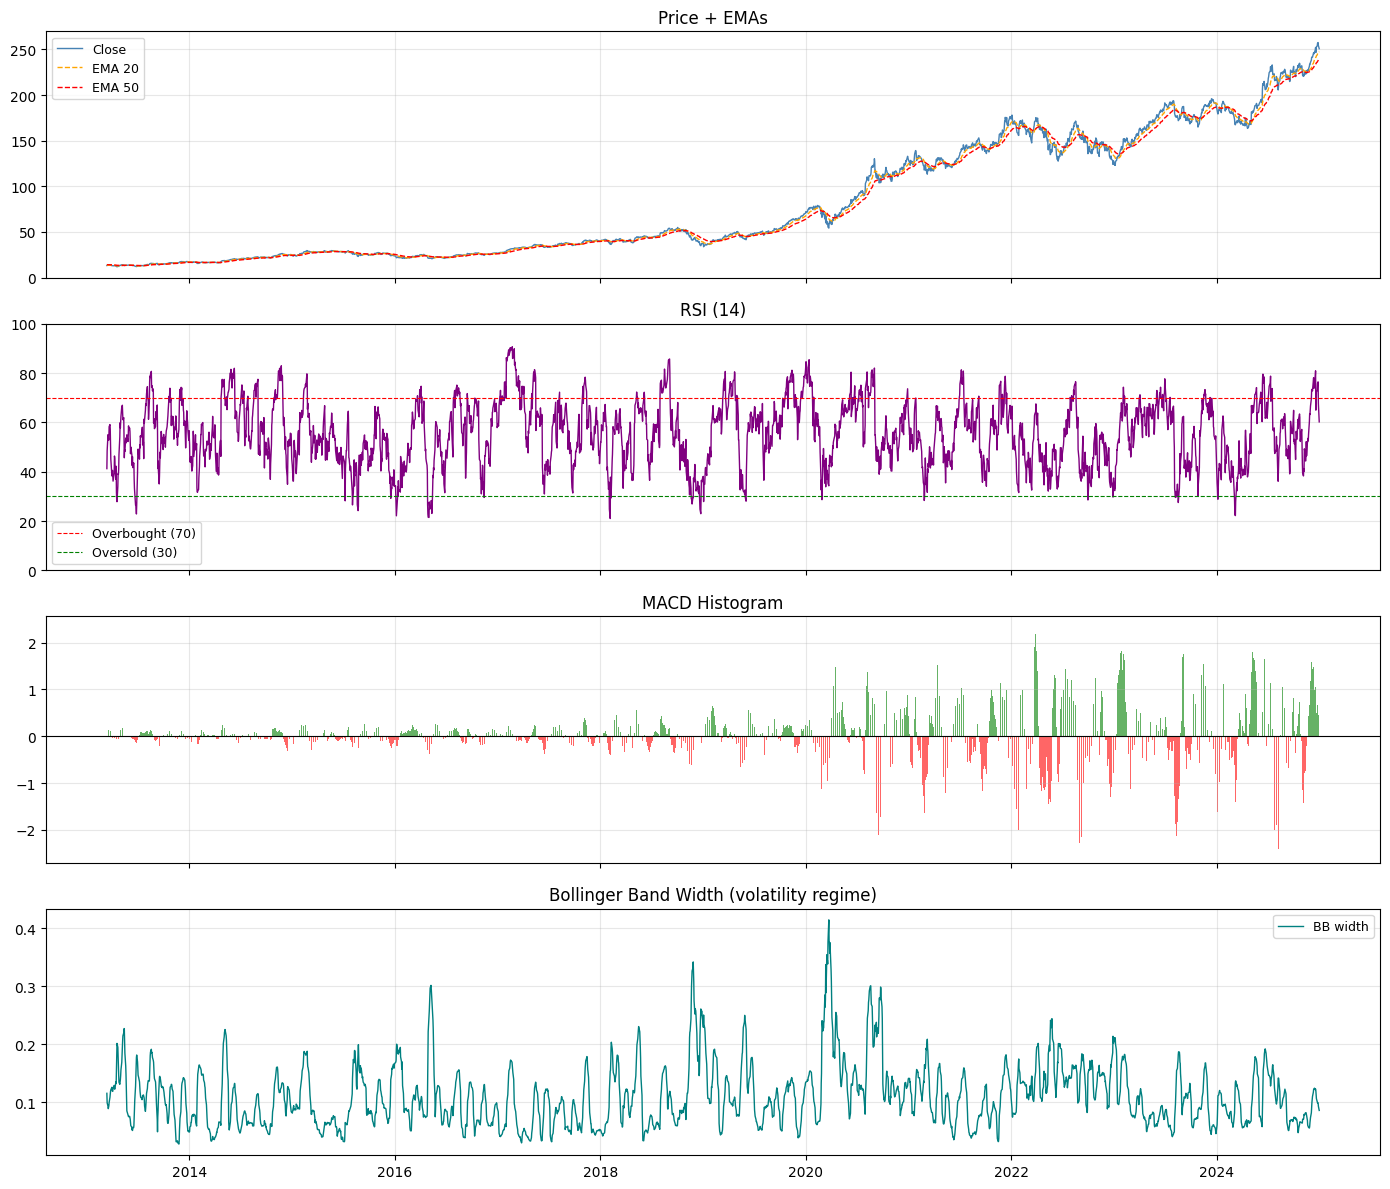

[PASS] Indicator plots rendered. Check RSI stays in [0,100] and MACD histogram is centered at 0.


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price + EMAs
axes[0].plot(df.index, df['Close'],  label='Close',  linewidth=1, color='steelblue')
axes[0].plot(df.index, df['ema_20'], label='EMA 20', linewidth=1, color='orange', linestyle='--')
axes[0].plot(df.index, df['ema_50'], label='EMA 50', linewidth=1, color='red',    linestyle='--')
axes[0].set_title('Price + EMAs')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df.index, df['rsi'], linewidth=1, color='purple')
axes[1].axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].set_title('RSI (14)')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# MACD histogram
colours = ['green' if x >= 0 else 'red' for x in df['macd']]
axes[2].bar(df.index, df['macd'], color=colours, alpha=0.6, width=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('MACD Histogram')
axes[2].grid(True, alpha=0.3)

# BB width + ATR (normalised)
axes[3].plot(df.index, df['bb_width'], label='BB width', linewidth=1, color='teal')
axes[3].set_title('Bollinger Band Width (volatility regime)')
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("[PASS] Indicator plots rendered. Check RSI stays in [0,100] and MACD histogram is centered at 0.")

---
## Cell 6 — Correlation matrix (check for redundant features)

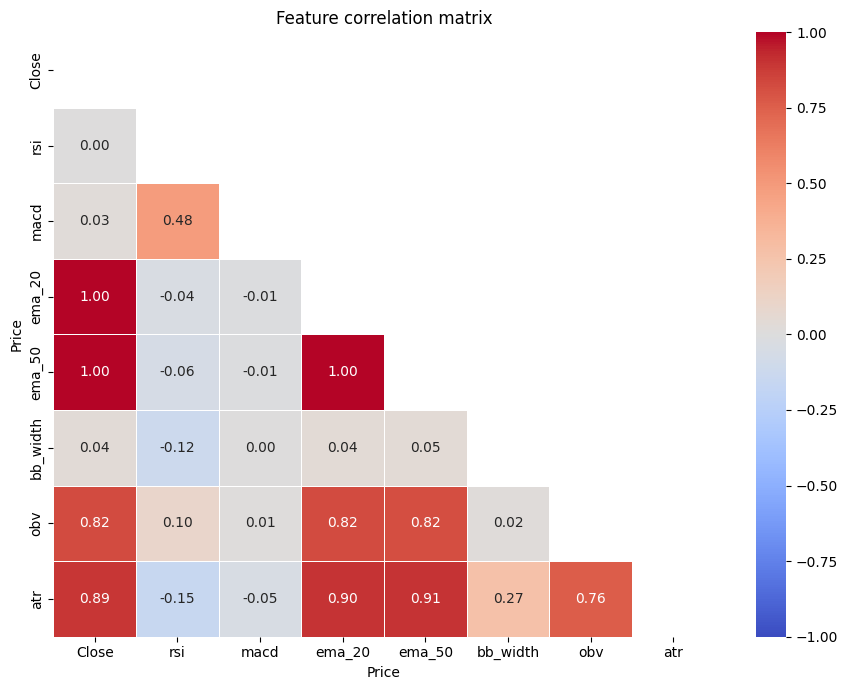

[WARN] Highly correlated pairs (>0.95) — consider dropping one:
       Close <-> ema_20  :  0.999
       Close <-> ema_50  :  0.996
       ema_20 <-> ema_50  :  0.999


In [7]:
import seaborn as sns
import numpy as np

corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

# Flag any suspiciously high correlations (>0.95) between feature pairs
high_corr = []
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        val = abs(corr.iloc[i, j])
        if val > 0.95:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], round(val, 3)))

if high_corr:
    print("[WARN] Highly correlated pairs (>0.95) — consider dropping one:")
    for a, b, v in high_corr:
        print(f"       {a} <-> {b}  :  {v}")
else:
    print("[PASS] No feature pairs with correlation > 0.95. Feature set looks healthy.")

---
## Cell 7 — Chronological train / val / test split

Train :  1713 rows  (57.7%)  2013-03-14 --> 2019-12-31
Val   :   505 rows  (17.0%)  2020-01-02 --> 2021-12-31
Test  :   752 rows  (25.3%)  2022-01-03 --> 2024-12-30



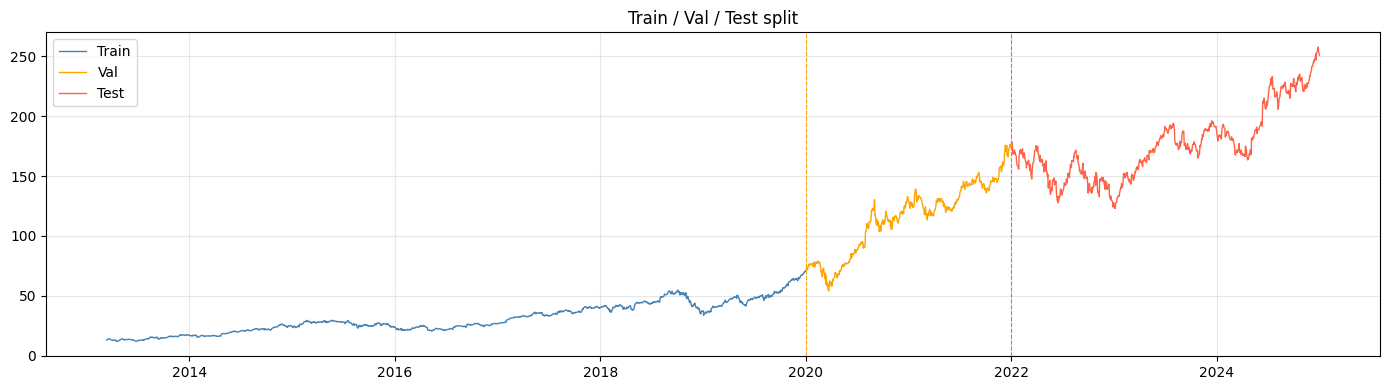

[PASS] No overlap between splits. Chronological order confirmed.


In [8]:
TRAIN_END = "2020-01-01"
VAL_END   = "2022-01-01"

train = df[df.index < TRAIN_END]
val   = df[(df.index >= TRAIN_END) & (df.index < VAL_END)]
test  = df[df.index >= VAL_END]

total = len(df)
print(f"Train : {len(train):>5} rows  ({len(train)/total*100:.1f}%)  "
      f"{train.index[0].date()} --> {train.index[-1].date()}")
print(f"Val   : {len(val):>5} rows  ({len(val)/total*100:.1f}%)  "
      f"{val.index[0].date()} --> {val.index[-1].date()}")
print(f"Test  : {len(test):>5} rows  ({len(test)/total*100:.1f}%)  "
      f"{test.index[0].date()} --> {test.index[-1].date()}")
print()

# Visualise the split on the price chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['Close'], label='Train', color='steelblue',  linewidth=1)
ax.plot(val.index,   val['Close'],   label='Val',   color='orange',     linewidth=1)
ax.plot(test.index,  test['Close'],  label='Test',  color='tomato',     linewidth=1)
ax.axvline(pd.Timestamp(TRAIN_END), color='orange', linestyle='--', linewidth=0.8)
ax.axvline(pd.Timestamp(VAL_END),   color='tomato', linestyle='--', linewidth=0.8)
ax.set_title('Train / Val / Test split')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Assertions
assert len(train) > 1500,             "FAIL: Train set too small"
assert len(val)   > 300,              "FAIL: Val set too small"
assert len(test)  > 300,              "FAIL: Test set too small"
assert train.index[-1] < val.index[0],  "FAIL: Train/val overlap detected — data leakage!"
assert val.index[-1]   < test.index[0], "FAIL: Val/test overlap detected — data leakage!"

print("[PASS] No overlap between splits. Chronological order confirmed.")

---
## Cell 8 — Normalise with RobustScaler

Scaled train statistics (should all be roughly in [-3, 3] range):
Price     Close       rsi      macd    ema_20    ema_50  bb_width       obv  \
count  1713.000  1713.000  1713.000  1713.000  1713.000  1713.000  1713.000   
mean      0.196    -0.023     0.002     0.200     0.204     0.162    -0.226   
std       0.675     0.718     0.943     0.677     0.665     0.756     0.765   
min      -0.833    -1.916    -3.705    -0.796    -0.762    -0.968    -2.816   
25%      -0.297    -0.525    -0.466    -0.283    -0.253    -0.427    -0.664   
50%       0.000     0.000     0.000     0.000     0.000     0.000     0.000   
75%       0.703     0.475     0.534     0.717     0.747     0.573     0.336   
max       2.312     1.846     3.816     2.202     2.059     3.777     0.976   

Price       atr  
count  1713.000  
mean      0.186  
std       0.781  
min      -0.805  
25%      -0.447  
50%       0.000  
75%       0.553  
max       3.086  



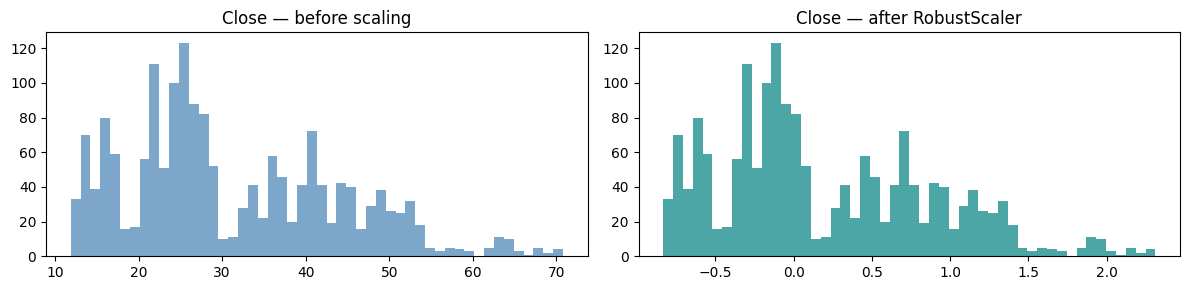

[PASS] Scaler fitted on train only. All features in comparable range.


In [9]:
from sklearn.preprocessing import RobustScaler
import numpy as np

train_s = train[FEATURE_COLS].copy()
val_s   = val[FEATURE_COLS].copy()
test_s  = test[FEATURE_COLS].copy()

scaler = RobustScaler()
train_s[FEATURE_COLS] = scaler.fit_transform(train_s)   # fit ONLY on train
val_s[FEATURE_COLS]   = scaler.transform(val_s)          # transform only
test_s[FEATURE_COLS]  = scaler.transform(test_s)          # transform only

print("Scaled train statistics (should all be roughly in [-3, 3] range):")
print(train_s.describe().round(3))
print()

# Check scaler was NOT re-fitted on val/test
# (we verify by checking train median ≈ 0 for all features)
medians = train_s.median()
for feat, med in medians.items():
    assert abs(med) < 0.1, f"FAIL: {feat} median after scaling is {med:.3f} — expected ~0"

# Visualise scale before vs after for Close price
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(train['Close'],   bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Close — before scaling')
axes[1].hist(train_s['Close'], bins=50, color='teal',      alpha=0.7)
axes[1].set_title('Close — after RobustScaler')
plt.tight_layout()
plt.show()

print("[PASS] Scaler fitted on train only. All features in comparable range.")

---
## Cell 9 — Return distribution per split

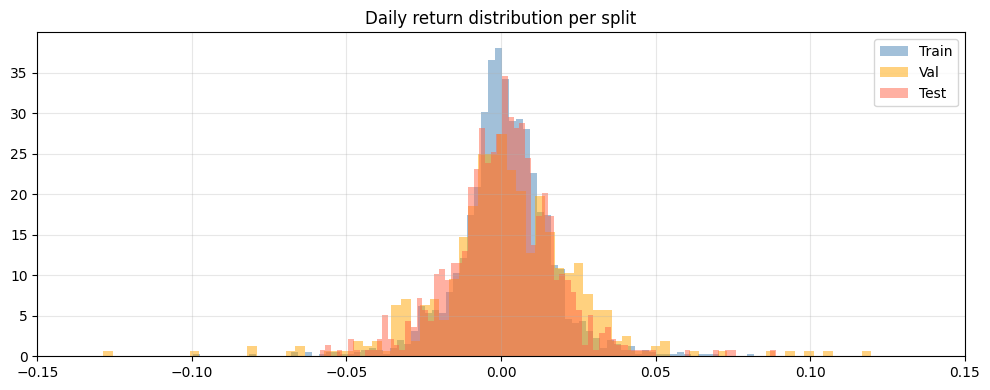

Return statistics per split:
  Train   mean=0.110%  std=1.535%  min=-9.96%  max=8.20%
  Val     mean=0.202%  std=2.360%  min=-12.86%  max=11.98%
  Test    mean=0.060%  std=1.708%  min=-5.87%  max=8.90%

[INFO] Val std should be noticeably higher than Train (COVID volatility).
[PASS] Val is more volatile than Train — expected. Splits look correct.


In [10]:
# Daily returns
r_train = train['Close'].pct_change().dropna()
r_val   = val['Close'].pct_change().dropna()
r_test  = test['Close'].pct_change().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(r_train, bins=80, alpha=0.5, label='Train', color='steelblue', density=True)
ax.hist(r_val,   bins=80, alpha=0.5, label='Val',   color='orange',    density=True)
ax.hist(r_test,  bins=80, alpha=0.5, label='Test',  color='tomato',    density=True)
ax.set_xlim(-0.15, 0.15)
ax.set_title('Daily return distribution per split')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Return statistics per split:")
for name, r in [('Train', r_train), ('Val', r_val), ('Test', r_test)]:
    print(f"  {name:<6}  mean={r.mean()*100:.3f}%  std={r.std()*100:.3f}%  "
          f"min={r.min()*100:.2f}%  max={r.max()*100:.2f}%")

print()
print("[INFO] Val std should be noticeably higher than Train (COVID volatility).")
if r_val.std() > r_train.std():
    print("[PASS] Val is more volatile than Train — expected. Splits look correct.")
else:
    print("[WARN] Val is not more volatile than Train — double-check your split dates.")

---
## Cell 10 — Save processed files

In [11]:
import os
import joblib

os.makedirs("../data/raw",       exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Save raw
raw_path = f"../data/raw/{TICKER}.csv"
raw.to_csv(raw_path)

# Save processed splits (scaled)
train_s.to_csv("../data/processed/train.csv")
val_s.to_csv("../data/processed/val.csv")
test_s.to_csv("../data/processed/test.csv")

# Save scaler
joblib.dump(scaler, "../data/processed/scaler.pkl")

# Verify files exist and are non-empty
files_to_check = [
    raw_path,
    "../data/processed/train.csv",
    "../data/processed/val.csv",
    "../data/processed/test.csv",
    "../data/processed/scaler.pkl",
]

all_saved = True
for fpath in files_to_check:
    size = os.path.getsize(fpath) if os.path.exists(fpath) else 0
    status = '[PASS]' if size > 0 else '[FAIL]'
    if size == 0:
        all_saved = False
    print(f"  {status}  {fpath:<45}  {size/1024:.1f} KB")

print()
if all_saved:
    print("==> Phase 2 complete. All files saved. Safe to move to Phase 3.")
else:
    print("==> Some files missing. Re-run the cells above and check for errors.")

  [PASS]  ../data/raw/AAPL.csv                           279.1 KB
  [PASS]  ../data/processed/train.csv                    282.9 KB
  [PASS]  ../data/processed/val.csv                      79.3 KB
  [PASS]  ../data/processed/test.csv                     118.0 KB
  [PASS]  ../data/processed/scaler.pkl                   0.9 KB

==> Phase 2 complete. All files saved. Safe to move to Phase 3.
